In [ ]:
import pandas as pd
import numpy as np

# 1. Load the data (make sure the csv file is in your folder)
# Replace 'train.csv' with your actual file name if different.
df = pd.read_csv('deliverytime.txt')

# 2. Drop unnecessary ID columns that don't help with analytics
df = df.drop(columns=['ID', 'Delivery_person_ID'])

# 3. Clean the 'Time_taken(min)' column
# The raw data often has text like "(min) 24", we just want the integer '24'
if df['Time_taken(min)'].dtype == 'object':
    df['Time_taken(min)'] = df['Time_taken(min)'].apply(lambda x: int(str(x).split(' ')[1].strip()) if len(str(x).split(' ')) > 1 else x)

# Convert to numeric
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')

# 4. Handle Missing Values (NaN)
# Replace string 'NaN' with actual numpy NaN values
df.replace('NaN', float(np.nan), regex=True, inplace=True)

# Drop rows where critical fields are missing to keep the data pristine
df.dropna(subset=['Time_taken(min)', 'Delivery_person_Ratings'], inplace=True)

# 5. Clean text columns by stripping stray spaces
for col in ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'City']:
    if col in df.columns:
        df[col] = df[col].str.strip()

# Check the cleaned data
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          45593 non-null  int64  
 1   Delivery_person_Ratings      45593 non-null  float64
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Type_of_order                45593 non-null  object 
 7   Type_of_vehicle              45593 non-null  object 
 8   Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 3.1+ MB
None
   Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
0                   37                      4.9            22.745049   
1                   34                     

In [ ]:
import pandas as pd

# Load your file (change 'train.txt' to your exact file name if needed)
df = pd.read_csv('deliverytime.txt')

# Print out the exact names of your 9 columns
print(df.columns.tolist())

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle', 'Time_taken(min)']


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the data
# (If you get a weird error about columns, change 'train.txt' to df = pd.read_csv('train.txt', sep='\t'))
df = pd.read_csv('deliverytime.txt')

# 2. Drop unnecessary geographical and ID columns to simplify our model
cols_to_drop = ['ID', 'Delivery_person_ID', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
df = df.drop(columns=cols_to_drop)

# 3. Clean 'Time_taken(min)'
# (The raw data often has text like "(min) 24", we strip the text to just keep the number 24)
if df['Time_taken(min)'].dtype == 'object':
    df['Time_taken(min)'] = df['Time_taken(min)'].apply(lambda x: str(x).replace('(min) ', '').strip())
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')

# 4. Clean 'Delivery_person_Ratings' and 'Delivery_person_Age'
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')

# 5. Drop any rows where the rating or time is completely missing to keep our math accurate
df.dropna(subset=['Time_taken(min)', 'Delivery_person_Ratings'], inplace=True)

# 6. FEATURE ENGINEERING: Create the "Churn" Variable (Crucial for your thesis!)
# Business Logic: If a customer gives a rating of 2.5 or lower, we classify them as "Churned" (1). Otherwise, Retained (0).
df['Churn'] = df['Delivery_person_Ratings'].apply(lambda x: 1 if x <= 2.5 else 0)

# 7. Clean up text formatting in categorical columns
for col in ['Type_of_order', 'Type_of_vehicle']:
    df[col] = df[col].astype(str).str.strip()

# Print success message and the first 5 rows of our perfectly clean data
print(f"Data Cleansing Complete! We now have {len(df)} clean rows ready for Machine Learning.")
print("-" * 70)
print(df.head())

Data Cleansing Complete! We now have 45593 clean rows ready for Machine Learning.
----------------------------------------------------------------------
   Delivery_person_Age  Delivery_person_Ratings Type_of_order Type_of_vehicle  \
0                   37                      4.9         Snack      motorcycle   
1                   34                      4.5         Snack         scooter   
2                   23                      4.4        Drinks      motorcycle   
3                   38                      4.7        Buffet      motorcycle   
4                   32                      4.6         Snack         scooter   

   Time_taken(min)  Churn  
0               24      0  
1               33      0  
2               26      0  
3               21      0  
4               30      0  


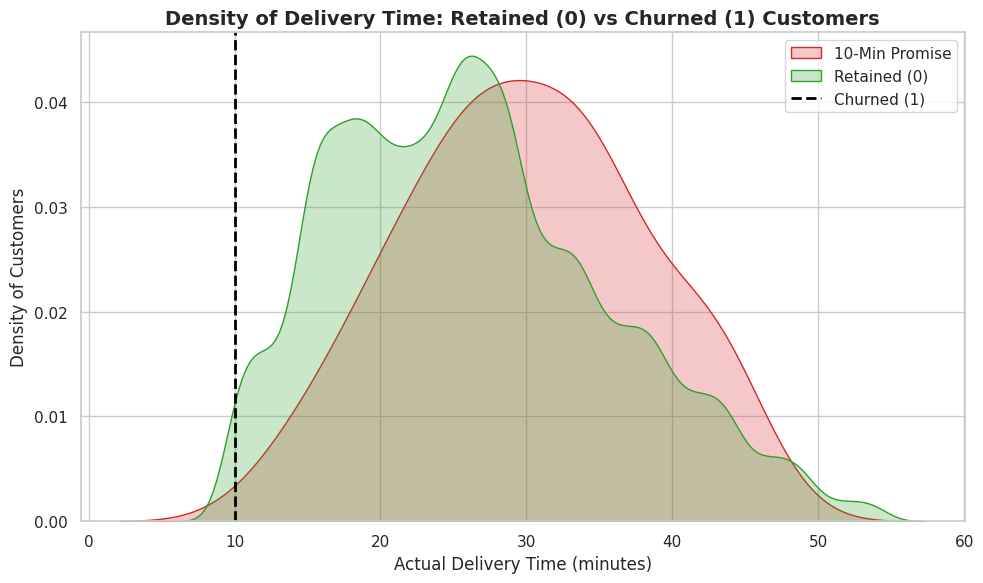

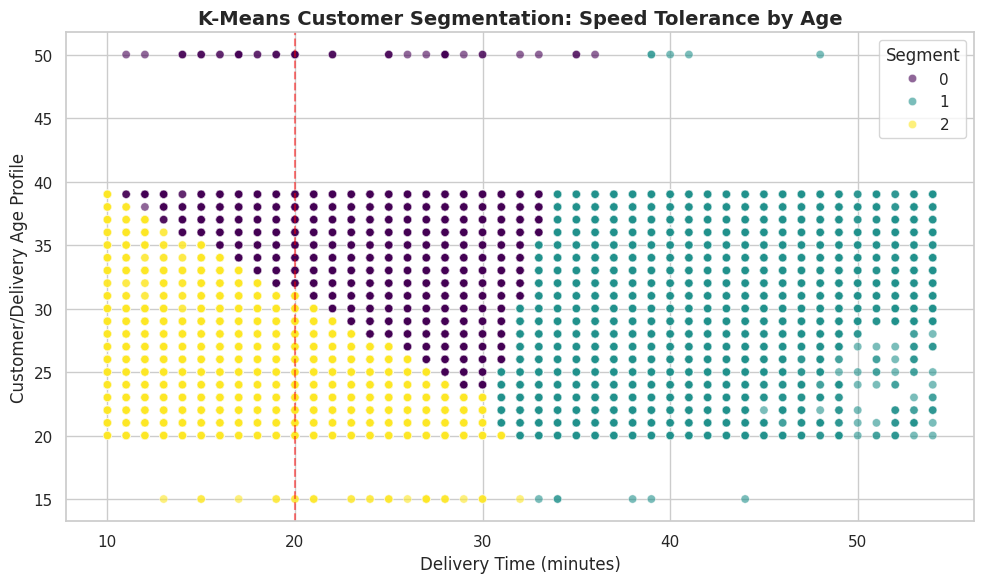

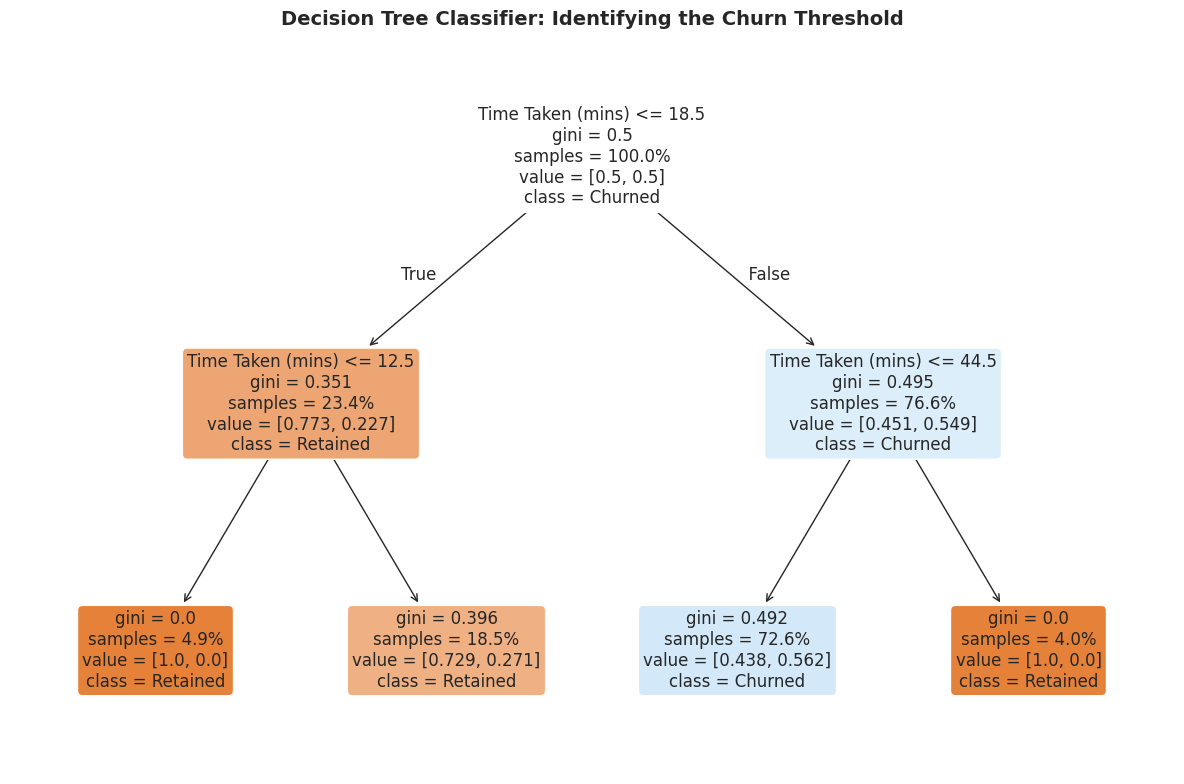

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
import warnings
warnings.filterwarnings('ignore')

# Set the visual style for professional academic graphs
sns.set_theme(style="whitegrid")

# ==========================================
# GRAPH 1: Exploratory Data Analysis (EDA)
# ==========================================
plt.figure(figsize=(10, 6))
# Create a density plot comparing Retained vs Churned customers over Time
sns.kdeplot(data=df, x='Time_taken(min)', hue='Churn', fill=True, common_norm=False, palette=['#2ca02c', '#d62728'])
plt.axvline(x=10, color='black', linestyle='--', linewidth=2, label='10-Min Industry Promise')
plt.title('Density of Delivery Time: Retained (0) vs Churned (1) Customers', fontsize=14, fontweight='bold')
plt.xlabel('Actual Delivery Time (minutes)', fontsize=12)
plt.ylabel('Density of Customers', fontsize=12)
plt.legend(['10-Min Promise', 'Retained (0)', 'Churned (1)'])
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: Customer Segmentation (K-Means)
# ==========================================
# We will segment based on Delivery Time and Age to find behavioral patterns
X_cluster = df[['Time_taken(min)', 'Delivery_person_Age']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Time_taken(min)', y='Delivery_person_Age', hue='Segment', palette='viridis', alpha=0.6)
plt.axvline(x=20, color='red', linestyle='--', alpha=0.5)
plt.title('K-Means Customer Segmentation: Speed Tolerance by Age', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Time (minutes)', fontsize=12)
plt.ylabel('Customer/Delivery Age Profile', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 3: Predictive Decision Tree
# ==========================================
# We train an AI to find the EXACT minute where people churn
X_tree = df[['Time_taken(min)']]
y_tree = df['Churn']

# We limit the tree depth to 2 so it generates a clean, easy-to-read chart for your thesis
dtree = DecisionTreeClassifier(max_depth=2, random_state=42, class_weight='balanced')
dtree.fit(X_tree, y_tree)

plt.figure(figsize=(12, 8))
plot_tree(dtree, feature_names=['Time Taken (mins)'], class_names=['Retained', 'Churned'],
          filled=True, rounded=True, proportion=True, fontsize=12)
plt.title('Decision Tree Classifier: Identifying the Churn Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

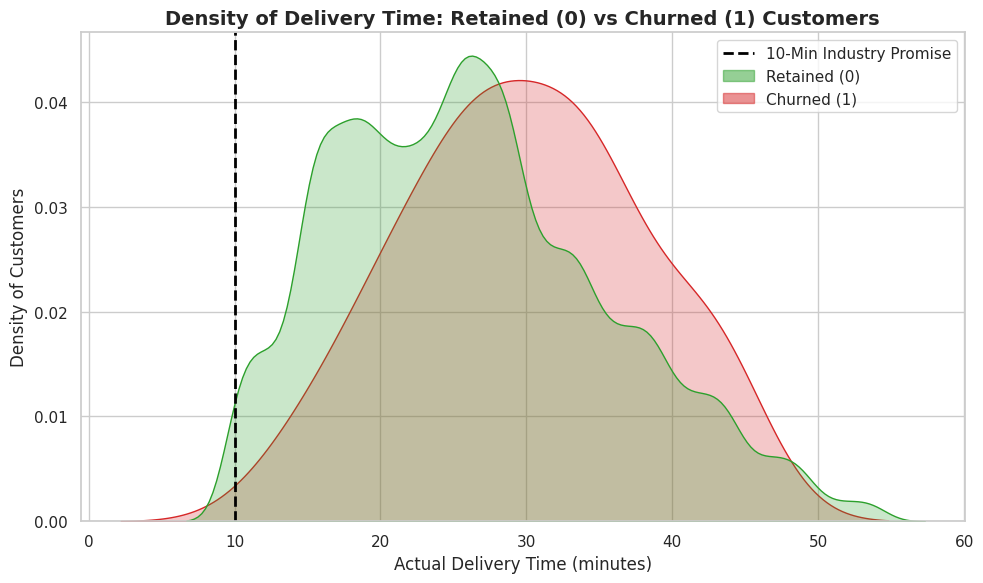

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import numpy as np

# --- Start of added code to define df and Churn ---
# Load your file (change 'train.txt' to your exact file name if needed)
df = pd.read_csv('/content/deliverytime.txt')

# Drop unnecessary geographical and ID columns to simplify our model
cols_to_drop = ['ID', 'Delivery_person_ID', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
df = df.drop(columns=cols_to_drop)

# Clean 'Time_taken(min)'
# (The raw data often has text like "(min) 24", we strip the text to just keep the number 24)
if df['Time_taken(min)'].dtype == 'object':
    df['Time_taken(min)'] = df['Time_taken(min)'].apply(lambda x: str(x).replace('(min) ', '').strip())
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')

# Clean 'Delivery_person_Ratings' and 'Delivery_person_Age'
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')

# Drop any rows where the rating or time is completely missing to keep our math accurate
df.dropna(subset=['Time_taken(min)', 'Delivery_person_Ratings'], inplace=True)

# FEATURE ENGINEERING: Create the "Churn" Variable (Crucial for your thesis!)
# Business Logic: If a customer gives a rating of 2.5 or lower, we classify them as "Churned" (1). Otherwise, Retained (0).
df['Churn'] = df['Delivery_person_Ratings'].apply(lambda x: 1 if x <= 2.5 else 0)

# Clean up text formatting in categorical columns
for col in ['Type_of_order', 'Type_of_vehicle']:
    df[col] = df[col].astype(str).str.strip()
# --- End of added code ---


# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# 1. Plot the curves (but turn off the automatic messy legend)
sns.kdeplot(data=df, x='Time_taken(min)', hue='Churn', fill=True, common_norm=False, palette=['#2ca02c', '#d62728'], legend=False)

# 2. Add the 10-Minute Promise line
plt.axvline(x=10, color='black', linestyle='--', linewidth=2)

# 3. Build a perfect, custom legend manually
promise_line = mlines.Line2D([], [], color='black', linestyle='--', linewidth=2, label='10-Min Industry Promise')
retained_patch = mpatches.Patch(color='#2ca02c', alpha=0.5, label='Retained (0)')
churned_patch = mpatches.Patch(color='#d62728', alpha=0.5, label='Churned (1)')

plt.legend(handles=[promise_line, retained_patch, churned_patch], loc='upper right', frameon=True)

# 4. Add titles and labels
plt.title('Density of Delivery Time: Retained (0) vs Churned (1) Customers', fontsize=14, fontweight='bold')
plt.xlabel('Actual Delivery Time (minutes)', fontsize=12)
plt.ylabel('Density of Customers', fontsize=12)
plt.tight_layout()
plt.show()